In [28]:
import numpy as np
import matplotlib.pyplot as plt
import time
import copy
import os
import sys
import glob

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import datasets
from torchvision.utils import make_grid
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split

# HuggingFace Hub for persistent checkpoint storage
os.system('pip install -q huggingface_hub kaggle')
from huggingface_hub import HfApi

torch.manual_seed(17)


In [29]:
import os
base_path="/kaggle/input/datasets/ambityga/imagenet100"
print(os.listdir(base_path))


['Labels.json', 'train.X1', 'train.X3', 'train.X4', 'train.X2', 'val.X']


In [30]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [31]:
train_parts = [
    f'{base_path}/train.X1',
    f'{base_path}/train.X2',
    f'{base_path}/train.X3',
    f'{base_path}/train.X4'
]

train_datasets = [datasets.ImageFolder(root=part, transform=train_transform) for part in train_parts]
val_dataset    = datasets.ImageFolder(root=f'{base_path}/val.X', transform=val_transform)

global_classes      = sorted(set(cls for ds in train_datasets for cls in ds.classes))
global_class_to_idx = {cls: i for i, cls in enumerate(global_classes)}
NUM_CLASSES         = len(global_classes)
print(f'Global class count: {NUM_CLASSES}')

def remap_dataset(ds, mapping):
    old_idx_to_class = {v: k for k, v in ds.class_to_idx.items()}
    remap = {old_idx: mapping[cls] for old_idx, cls in old_idx_to_class.items()}
    ds.samples      = [(path, remap[label]) for path, label in ds.samples]
    ds.targets      = [remap[label] for label in ds.targets]
    ds.class_to_idx = mapping
    ds.classes      = global_classes

for ds in train_datasets:
    remap_dataset(ds, global_class_to_idx)
remap_dataset(val_dataset, global_class_to_idx)

full_train_dataset = ConcatDataset(train_datasets)

print(f'Train images : {len(full_train_dataset)}')
print(f'Val images   : {len(val_dataset)}')
print(f'Sample classes (first 5): {global_classes[:5]}')


Global class count: 100
Train images : 130000
Val images   : 5000
Sample classes (first 5): ['n01440764', 'n01443537', 'n01484850', 'n01491361', 'n01494475']


In [32]:
print('Merging targets...')
all_targets = np.array([label for _, label in full_train_dataset.datasets[0].samples]
                       + [label for ds in full_train_dataset.datasets[1:] for _, label in ds.samples])

print('Splitting...')
train_indices, test_indices = train_test_split(
    np.arange(len(all_targets)),
    test_size=5000,
    stratify=all_targets,
    random_state=42,
    shuffle=True
)

final_train_dataset = Subset(full_train_dataset, train_indices)
final_test_dataset  = Subset(full_train_dataset, test_indices)
print(f'Train: {len(final_train_dataset)} | Test: {len(final_test_dataset)}')


Merging targets...
Splitting...
Train: 125000 | Test: 5000


In [33]:
batch_size = 128

train_loader = DataLoader(final_train_dataset, batch_size=batch_size, shuffle=True,  num_workers=4,persistent_workers=True, pin_memory=True)
val_loader   = DataLoader(val_dataset,         batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True, pin_memory=True)
test_loader  = DataLoader(final_test_dataset,  batch_size=batch_size, shuffle=False, num_workers=4,persistent_workers=True, pin_memory=True)


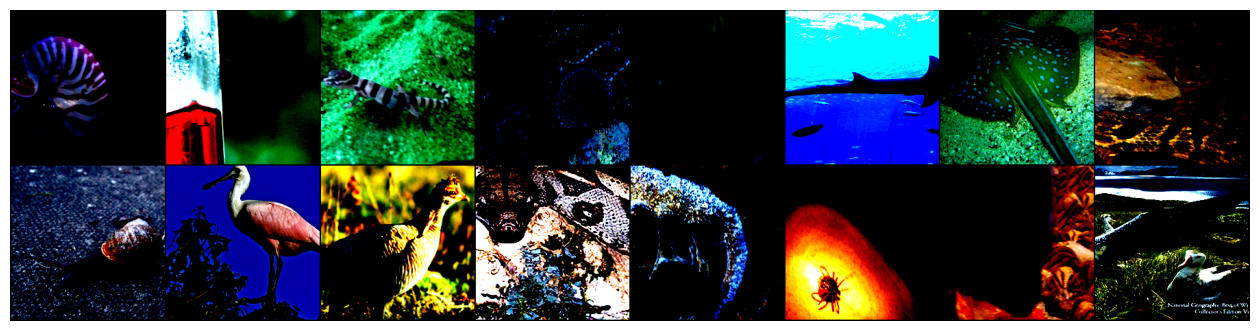

In [34]:
for images, _ in train_loader:
    plt.figure(figsize=(16, 8))
    plt.axis('off')
    plt.imshow(make_grid(images[:16], nrow=8).permute(1, 2, 0).clip(0, 1))
    break

In [35]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, identity_downsample=None, stride=1):
        super(ResidualBlock, self).__init__()
        self.expansion = 4
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1, padding=0)  
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1) 
        self.bn2   = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, padding=0)
        self.bn3   = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu  = nn.ReLU()
        self.identity_downsample = identity_downsample

    def forward(self, x):
        identity = x
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.bn3(self.conv3(x))  
        if self.identity_downsample is not None:
            identity = self.identity_downsample(identity)
        x += identity
        x = self.relu(x)
        return x


class ResNet(nn.Module):
    def __init__(self, block, layers, image_channels, num_classes):
        super(ResNet, self).__init__()
        self.in_channels = 64  # fixed: was in__channels
        self.conv1   = nn.Conv2d(image_channels, 64, kernel_size=7, stride=2, padding=3)
        self.bn1     = nn.BatchNorm2d(64)
        self.relu    = nn.ReLU()
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1  = self._make_layer(block, layers[0], out_channels=64,  stride=1)
        self.layer2  = self._make_layer(block, layers[1], out_channels=128, stride=2)
        self.layer3  = self._make_layer(block, layers[2], out_channels=256, stride=2) 
        self.layer4  = self._make_layer(block, layers[3], out_channels=512, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc      = nn.Linear(512 * 4, num_classes)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x) 
        return x

    def _make_layer(self, block, num_residual_blocks, out_channels, stride):
        identity_downsample = None
        layers = []
        if stride != 1 or self.in_channels != out_channels * 4:
            identity_downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * 4, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels * 4)
            )
        layers.append(block(self.in_channels, out_channels, identity_downsample, stride))
        self.in_channels = out_channels * 4
        for i in range(num_residual_blocks - 1):  # fixed: was num_residual_block
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)


model = ResNet(ResidualBlock, [3, 4, 6, 3], image_channels=3, num_classes=100)
x = torch.randn(2, 3, 224, 224)
print(model(x).shape) 

torch.Size([2, 100])


In [36]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using: {device}')

model = model
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

model.to(device)

Using: cuda:0
Using 2 GPUs


DataParallel(
  (module): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): ResidualBlock(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU()
        (identity_downsample): Sequential(
          (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1))


In [ ]:
import os
import glob
from huggingface_hub import HfApi, login

EPOCHS    = 100
SAVE_DIR  = "kaggle/working/checkpoint"
os.makedirs(SAVE_DIR, exist_ok=True) 

HF_TOKEN   = 'YOUR_HF_TOKEN'          
login(token=HF_TOKEN)

HF_REPO_ID = 'YOUR_HF_REPO'  
hf_api     = HfApi(token=HF_TOKEN)

existing    = sorted(glob.glob(f'{SAVE_DIR}/checkpoint_epoch_*.pth'))
AUTO_RESUME = existing[-1] if existing else None
if AUTO_RESUME:
    print(f'Will resume from: {AUTO_RESUME}')
else:
    print('No checkpoint found — starting fresh')

criterion    = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer    = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

Will resume from: kaggle/working/checkpoint/checkpoint_epoch_070.pth


In [38]:


def upload_to_hf(local_path):
    """Upload a file to HuggingFace Hub. Silently skips if token not set."""
    if HF_TOKEN == '':
        return  # not configured yet
    try:
        hf_api.upload_file(
            path_or_fileobj = local_path,
            path_in_repo    = os.path.basename(local_path),
            repo_id         = HF_REPO_ID,
            repo_type       = 'model',
            token           = HF_TOKEN,
        )
        print(f'  [HF] Uploaded {os.path.basename(local_path)} -> {HF_REPO_ID}')
    except Exception as e:
        print(f'  [HF] Upload failed (non-fatal): {e}')


def save_checkpoint(epoch, model, optimizer, scheduler, best_acc, val_acc_history, path):
    state = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    torch.save({
        'epoch':            epoch,
        'model_state_dict': state,
        'optim_state_dict': optimizer.state_dict(),
        'sched_state_dict': scheduler.state_dict(),
        'best_acc':         best_acc,
        'val_acc_history':  val_acc_history,
    }, path)
    print(f'  [Checkpoint] Saved -> {path}')
    sys.stdout.flush()  # force output so Kaggle doesn't think kernel is idle
    upload_to_hf(path)  # push to HF immediately after saving


def load_checkpoint(path, model, optimizer, scheduler):
    ckpt  = torch.load(path, map_location=device)
    inner = model.module if isinstance(model, nn.DataParallel) else model
    inner.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optim_state_dict'])
    scheduler.load_state_dict(ckpt['sched_state_dict'])
    print(f'  [Resume] Epoch {ckpt["epoch"]} | Best acc: {ckpt["best_acc"]:.4f}')
    return ckpt['epoch'] + 1, ckpt['best_acc'], ckpt['val_acc_history']


In [39]:
from torch.cuda.amp import GradScaler, autocast

scaler = torch.amp.GradScaler('cuda')

def train_model(
    model, dataloaders, criterion, optimizer, scheduler,
    num_epochs=100, use_auxiliary=False,
    save_dir=SAVE_DIR,
    checkpoint_every=1,
    resume_from=None,
):
    since           = time.time()
    val_acc_history = []
    best_acc        = 0.0
    best_model_wts  = copy.deepcopy(model.state_dict())
    start_epoch     = 0

    if resume_from and os.path.isfile(resume_from):
        start_epoch, best_acc, val_acc_history = load_checkpoint(
            resume_from, model, optimizer, scheduler
        )
        best_model_wts = copy.deepcopy(model.state_dict())

    for epoch in range(start_epoch, num_epochs):
        print(f'\nEpoch {epoch}/{num_epochs - 1}')
        print('-' * 40)
        sys.stdout.flush()

        for phase in ['train', 'val']:
            model.train() if phase == 'train' else model.eval()
            running_loss     = 0.0
            running_corrects = 0
            pbar = tqdm(dataloaders[phase], desc=f'{phase.capitalize()} {epoch+1}/{num_epochs}', leave=False)

            for inputs, labels in pbar:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad(set_to_none=True)  # faster

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast():  # mixed precision
                        if phase == 'train':
                            if use_auxiliary:
                                outputs, aux1, aux2 = model(inputs)
                                loss = (
                                    criterion(outputs, labels)
                                    + 0.3 * criterion(aux1, labels)
                                    + 0.3 * criterion(aux2, labels)
                                )
                            else:
                                outputs = model(inputs)
                                loss = criterion(outputs, labels)
                        else:
                            outputs = model(inputs)
                            loss = criterion(outputs, labels)

                if phase == 'train':
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                    scaler.step(optimizer)
                    scaler.update()

                _, preds = torch.max(outputs, 1)
                running_loss     += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                pbar.set_postfix(loss=f'{loss.item():.4f}')
                del inputs, labels, outputs

            # empty cache once per epoch, not per batch
            torch.cuda.empty_cache()

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc  = running_corrects.double() / len(dataloaders[phase].dataset)
            print(f'  {phase.upper():5s} | Loss: {epoch_loss:.4f}  Acc: {epoch_acc:.4f}')
            sys.stdout.flush()

            if phase == 'val':
                val_acc_history.append(epoch_acc.item())
                if epoch_acc > best_acc:
                    best_acc       = epoch_acc
                    best_model_wts = copy.deepcopy(model.state_dict())
                    best_path      = os.path.join(save_dir, 'best_model.pth')
                    save_checkpoint(epoch, model, optimizer, scheduler, best_acc, val_acc_history, best_path)
                    print(f'  [Best] New best val acc: {best_acc:.4f}')

        scheduler.step()
        print(f'  LR: {optimizer.param_groups[0]["lr"]:.2e}')

        if (epoch + 1) % checkpoint_every == 0:
            periodic_path = os.path.join(save_dir, f'checkpoint_epoch_{epoch+1:03d}.pth')
            save_checkpoint(epoch, model, optimizer, scheduler, best_acc, val_acc_history, periodic_path)

        print()

    elapsed = time.time() - since
    print(f'Training complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')
    model.load_state_dict(best_model_wts)
    return model, val_acc_history

In [ ]:
model, history = train_model(
    model,
    dataloaders      = {'train': train_loader, 'val': val_loader},
    criterion        = criterion,
    optimizer        = optimizer,
    scheduler        = lr_scheduler,
    num_epochs       = EPOCHS,
    use_auxiliary    = False,  
    save_dir         = SAVE_DIR,
    checkpoint_every = 1,
    resume_from      = AUTO_RESUME,
)


  [Resume] Epoch 69 | Best acc: 0.7952

Epoch 70/99
----------------------------------------


Train 71/100:   0%|          | 0/977 [00:00<?, ?it/s]

/tmp/ipykernel_58/2368803355.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():  # mixed precision


  TRAIN | Loss: 1.4667  Acc: 0.7940


Val 71/100:   0%|          | 0/40 [00:00<?, ?it/s]

...

  VAL   | Loss: 1.3867  Acc: 0.8150
  LR: 2.54e-05
  [Checkpoint] Saved -> kaggle/working/checkpoint/checkpoint_epoch_090.pth


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

  [HF] Uploaded checkpoint_epoch_090.pth -> chitransh001/ResNet50


Epoch 90/99
----------------------------------------


Train 91/100:   0%|          | 0/977 [00:00<?, ?it/s]